In [1]:
!sudo apt-get install build-essential swig 
!pip install gymnasium[box2d]

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
build-essential is already the newest version (12.9ubuntu3).
Suggested packages:
  swig-doc swig-examples swig4.0-examples swig4.0-doc
The following NEW packages will be installed:
  swig swig4.0
0 upgraded, 2 newly installed, 0 to remove and 133 not upgraded.
Need to get 1,116 kB of archives.
After this operation, 5,542 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig4.0 amd64 4.0.2-1ubuntu1 [1,110 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 swig all 4.0.2-1ubuntu1 [5,632 B]
Fetched 1,116 kB in 1s (1,226 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 2.)
debconf: falling back to frontend: Readline
Selecting previously unselected package swig4.0.
(

In [2]:
import math
import random
from collections import deque, namedtuple
from dataclasses import dataclass

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.notebook import tqdm

In [3]:
@dataclass
class Args:
    """SAC hyperparameters."""
    env_name: str = "LunarLanderContinuous-v3"
    seed: int = 42

    # Training hyperparameters
    gamma: float = 0.99
    tau: float = 0.005
    policy_lr: float = 3e-4
    q_lr: float = 3e-4
    hidden_sizes: tuple[int, ...] = (256, 256)
    auto_alpha: bool = False
    target_entropy: float | None = None

    # Replay buffer settings
    buffer_size: int = 1_000_000
    total_steps: int = 300_000
    start_steps: int = 10000
    update_after: int = 10000
    update_every: int = 10
    batch_size: int = 256
    eval_every: int = 5_000
    max_ep_len: int = 1000


args = Args()

In [4]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility across all libraries."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def mlp(sizes: tuple[int, ...], activation: type = nn.ReLU, output_activation: type = nn.Identity) -> nn.Sequential:
    """Create a multi-layer perceptron.

    Args:
        sizes: Tuple of layer sizes
        activation: Hidden layer activation function
        output_activation: Output layer activation function

    Returns:
        Sequential network
    """
    layers = []
    for i in range(len(sizes) - 1):
        act = activation if i < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[i], sizes[i + 1]), act()]
    return nn.Sequential(*layers)

In [5]:
LOG_STD_MIN = -20
LOG_STD_MAX = 2


class SquashedGaussianActor(nn.Module):
    """Gaussian actor with tanh squashing for continuous actions."""

    def __init__(self, obs_dim: int, act_dim: int, hidden_sizes: tuple[int, ...], act_limit: float):
        super().__init__()
        self.net = mlp([obs_dim] + list(hidden_sizes), nn.ReLU, nn.ReLU)
        self.mu_layer = nn.Linear(hidden_sizes[-1], act_dim)
        self.log_std_layer = nn.Linear(hidden_sizes[-1], act_dim)
        self.act_limit = act_limit

    def forward(
        self,
        obs: torch.Tensor,
        deterministic: bool = False,
        with_logprob: bool = True
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        """Forward pass through the actor.

        Args:
            obs: Observation tensor
            deterministic: If True, return deterministic action
            with_logprob: If True, compute log probability

        Returns:
            Tuple of (action, log_prob) where log_prob is None if with_logprob=False
        """
        h = self.net(obs)
        mu = self.mu_layer(h)
        log_std = self.log_std_layer(h)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std)

        dist = torch.distributions.Normal(mu, std)

        if deterministic:
            pre_tanh = mu
        else:
            pre_tanh = dist.rsample()  # reparameterization trick

        if with_logprob:
            logp = dist.log_prob(pre_tanh).sum(dim=-1, keepdim=True)
            # tanh correction
            logp -= (2 * (math.log(2) - pre_tanh - F.softplus(-2 * pre_tanh))).sum(dim=-1, keepdim=True)
        else:
            logp = None

        action = torch.tanh(pre_tanh)
        action = self.act_limit * action
        return action, logp


class QFunction(nn.Module):
    """Q-function network that takes state and action as input."""

    def __init__(self, obs_dim: int, act_dim: int, hidden_sizes: tuple[int, ...]):
        super().__init__()
        self.q = mlp([obs_dim + act_dim] + list(hidden_sizes) + [1], nn.ReLU, nn.Identity)

    def forward(self, obs: torch.Tensor, act: torch.Tensor) -> torch.Tensor:
        """Forward pass through the Q-network."""
        x = torch.cat([obs, act], dim=-1)
        return self.q(x)

In [6]:
Transition = namedtuple("Transition", ["obs", "act", "rew", "next_obs", "done"])


class ReplayBuffer:
    """Circular replay buffer for continuous control."""

    def __init__(self, obs_dim: int, act_dim: int, size: int):
        self.obs = np.zeros((size, obs_dim), dtype=np.float32)
        self.next_obs = np.zeros((size, obs_dim), dtype=np.float32)
        self.acts = np.zeros((size, act_dim), dtype=np.float32)
        self.rews = np.zeros((size, 1), dtype=np.float32)
        self.done = np.zeros((size, 1), dtype=np.float32)

        self.ptr = 0
        self.size = 0
        self.max_size = size

    def add(self, obs, act, rew, next_obs, done) -> None:
        """Add a transition to the buffer."""
        self.obs[self.ptr] = obs
        self.acts[self.ptr] = act
        self.rews[self.ptr] = rew
        self.next_obs[self.ptr] = next_obs
        self.done[self.ptr] = done

        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size: int, device: torch.device) -> dict[str, torch.Tensor]:
        """Sample a random batch from the buffer."""
        idxs = np.random.randint(0, self.size, size=batch_size)
        batch = dict(
            obs=torch.tensor(self.obs[idxs], device=device),
            act=torch.tensor(self.acts[idxs], device=device),
            rew=torch.tensor(self.rews[idxs], device=device),
            next_obs=torch.tensor(self.next_obs[idxs], device=device),
            done=torch.tensor(self.done[idxs], device=device),
        )
        return batch

In [7]:
class SACAgent:
    """Soft Actor-Critic agent for continuous control."""

    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        act_limit: float,
        device: torch.device,
        gamma: float = 0.99,
        tau: float = 0.005,
        policy_lr: float = 1e-4,
        q_lr: float = 3e-4,
        hidden_sizes: tuple[int, ...] = (256, 256),
        auto_alpha: bool = True,
        target_entropy: float | None = None,
    ):
        self.device = device
        self.gamma = gamma
        self.tau = tau
        self.act_limit = act_limit
        self.auto_alpha = auto_alpha

        # Actor
        self.actor = SquashedGaussianActor(obs_dim, act_dim, hidden_sizes, act_limit).to(device)

        # Critic networks
        self.q1 = QFunction(obs_dim, act_dim, hidden_sizes).to(device)
        self.q2 = QFunction(obs_dim, act_dim, hidden_sizes).to(device)

        # Target networks
        self.q1_target = QFunction(obs_dim, act_dim, hidden_sizes).to(device)
        self.q2_target = QFunction(obs_dim, act_dim, hidden_sizes).to(device)
        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())

        # Optimizers
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=policy_lr)
        self.q1_opt = optim.Adam(self.q1.parameters(), lr=q_lr)
        self.q2_opt = optim.Adam(self.q2.parameters(), lr=q_lr)

        # Temperature
        if target_entropy is None:
            target_entropy = -act_dim
        self.target_entropy = target_entropy

        if auto_alpha:
            self.log_alpha = torch.tensor(0.0, requires_grad=True, device=device)
            self.alpha_opt = optim.Adam([self.log_alpha], lr=q_lr)
        else:
            self._alpha = 0.2

    @property
    def alpha(self) -> float:
        """Get current temperature value."""
        if self.auto_alpha:
            return self.log_alpha.exp().item()
        return self._alpha

    @alpha.setter
    def alpha(self, value: float) -> None:
        """Set temperature value."""
        self._alpha = value

    def select_action(self, obs: np.ndarray, deterministic: bool = False) -> np.ndarray:
        """Select action for given observation.

        Args:
            obs: Observation array
            deterministic: If True, use deterministic action (for evaluation)

        Returns:
            Action array
        """
        obs_t = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            action, _ = self.actor(obs_t, deterministic=deterministic, with_logprob=False)
        return action.cpu().numpy()[0]

    def update(self, batch: dict[str, torch.Tensor]) -> dict[str, float]:
        """Update all networks from a batch of data.

        Args:
            batch: Dictionary of tensors from replay buffer

        Returns:
            Dictionary of loss values
        """
        obs = batch["obs"]
        act = batch["act"]
        rew = batch["rew"]
        next_obs = batch["next_obs"]
        done = batch["done"]

        # -------------------------
        # Q update
        # -------------------------
        with torch.no_grad():
            next_act, next_logp = self.actor(next_obs, deterministic=False, with_logprob=True)
            q1_target_next = self.q1_target(next_obs, next_act)
            q2_target_next = self.q2_target(next_obs, next_act)
            q_target_next = torch.min(q1_target_next, q2_target_next) - self.alpha * next_logp
            backup = rew + self.gamma * (1.0 - done) * q_target_next

        q1_pred = self.q1(obs, act)
        q2_pred = self.q2(obs, act)

        q1_loss = F.mse_loss(q1_pred, backup)
        q2_loss = F.mse_loss(q2_pred, backup)
        q_loss = q1_loss + q2_loss

        self.q1_opt.zero_grad()
        self.q2_opt.zero_grad()
        q_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q1.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(self.q2.parameters(), 1.0)
        self.q1_opt.step()
        self.q2_opt.step()

        # -------------------------
        # Policy update
        # -------------------------
        for p in self.q1.parameters():
            p.requires_grad = False
        for p in self.q2.parameters():
            p.requires_grad = False

        pi, logp_pi = self.actor(obs, deterministic=False, with_logprob=True)
        q1_pi = self.q1(obs, pi)
        q2_pi = self.q2(obs, pi)
        q_pi = torch.min(q1_pi, q2_pi)

        actor_loss = (self.alpha * logp_pi - q_pi).mean()

        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        for p in self.q1.parameters():
            p.requires_grad = True
        for p in self.q2.parameters():
            p.requires_grad = True

        # -------------------------
        # Temperature update
        # -------------------------
        alpha_loss = torch.tensor(0.0, device=self.device)
        if self.auto_alpha:
            alpha_loss = -(self.log_alpha * (logp_pi + self.target_entropy).detach()).mean()
            self.alpha_opt.zero_grad()
            alpha_loss.backward()
            self.alpha_opt.step()

        # -------------------------
        # Target update
        # -------------------------
        with torch.no_grad():
            for p, p_targ in zip(self.q1.parameters(), self.q1_target.parameters()):
                p_targ.data.mul_(1 - self.tau)
                p_targ.data.add_(self.tau * p.data)

            for p, p_targ in zip(self.q2.parameters(), self.q2_target.parameters()):
                p_targ.data.mul_(1 - self.tau)
                p_targ.data.add_(self.tau * p.data)

        return {
            "q_loss": q_loss.item(),
            "actor_loss": actor_loss.item(),
            "alpha_loss": alpha_loss.item() if self.auto_alpha else 0.0,
            "alpha": self.alpha,
            "q1": q1_pred.mean().item(),
            "q2": q2_pred.mean().item(),
            "q1_loss": q1_loss.item(),
            "q2_loss": q2_loss.item(),
        }

In [8]:
def evaluate(agent: SACAgent, env: gym.Env, device: torch.device, episodes: int = 5, render: bool = False) -> float:
    """Evaluate agent performance over multiple episodes.

    Args:
        agent: SAC agent to evaluate
        env: Environment
        device: Device for tensors
        episodes: Number of episodes

    Returns:
        Average total reward
    """
    rewards = []

    for ep in range(episodes):
        if render:
            env.close()
            env = gym.make(args.env_name, render_mode="human")

        state, _ = env.reset(seed=args.seed + ep)
        done = False
        truncated = False
        total_reward = 0.0

        while not (done or truncated):
            action = agent.select_action(state, deterministic=True)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

    return float(np.mean(rewards))

In [9]:
def train() -> dict:
    """Train SAC agent on LunarLanderContinuous-v3.

    Returns:
        Dictionary containing training history
    """
    set_seed(args.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    env = gym.make(args.env_name)
    eval_env = gym.make(args.env_name)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    act_limit = float(env.action_space.high[0])

    agent = SACAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        act_limit=act_limit,
        device=device,
        gamma=args.gamma,
        tau=args.tau,
        policy_lr=args.policy_lr,
        q_lr=args.q_lr,
        hidden_sizes=args.hidden_sizes,
        auto_alpha=args.auto_alpha,
    )

    replay = ReplayBuffer(obs_dim, act_dim, size=args.buffer_size)

    obs, _ = env.reset(seed=args.seed)
    ep_return = 0.0
    ep_len = 0

    # History tracking
    eval_rets = []
    eval_steps = []
    q_l = []
    q1_l = []
    q2_l = []
    act_l = []
    alp_l = []
    alpha_v = []
    q1_val = []
    q2_val = []
    update_steps = []

    for t in tqdm(range(1, args.total_steps + 1)):
        # Collect experience
        if t < args.start_steps:
            action = env.action_space.sample()
        else:
            action = agent.select_action(obs, deterministic=False)

        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        ep_return += reward
        ep_len += 1

        done_for_buffer = float(terminated)  # truncation is time-limit, not true terminal
        replay.add(obs, action, reward, next_obs, done_for_buffer)
        obs = next_obs

        # Handle episode end
        if done or (ep_len == args.max_ep_len):
            obs, _ = env.reset()
            ep_return = 0.0
            ep_len = 0

        # Train network
        if t >= args.update_after and t % args.update_every == 0:
            q_losses = []
            q1_losses = []
            q2_losses = []
            actor_losses = []
            alpha_losses = []
            alpha_vals = []
            q1_vals = []
            q2_vals = []
            for _ in range(args.update_every):
                batch = replay.sample(args.batch_size, device)
                info = agent.update(batch)
                q_losses.append(info["q_loss"])
                q1_losses.append(info["q1_loss"])
                q2_losses.append(info["q2_loss"])
                actor_losses.append(info["actor_loss"])
                alpha_losses.append(info['alpha_loss'])
                alpha_vals.append(info['alpha'])
                q1_vals.append(info['q1'])
                q2_vals.append(info['q2'])
            mean_q_loss = np.mean(q_losses)
            mean_actor_loss = np.mean(actor_losses)
            mean_alpha_loss = np.mean(alpha_losses)
            q_l.append(mean_q_loss)
            act_l.append(mean_actor_loss)
            alp_l.append(mean_alpha_loss)
            q1_l.append(np.mean(q1_losses))
            q2_l.append(np.mean(q2_losses))
            alpha_v.append(np.mean(alpha_vals))
            q1_val.append(np.mean(q1_vals))
            q2_val.append(np.mean(q2_vals))
            update_steps.append(t)

        # Periodic evaluation
        if t % args.eval_every == 0 and t >= args.update_after:
            avg_ret = evaluate(agent, eval_env, device, episodes=10)
            eval_rets.append(avg_ret)
            eval_steps.append(t)
            print(f"[eval] step={t} avg_return={avg_ret:.1f} alpha={info['alpha']:.4f}")
            
    
    env.close()

    return {
        'eval_rets': eval_rets,
        'eval_steps': eval_steps,
        'q_l': q_l,
        'q1_l': q1_l,
        'q2_l': q2_l,
        'act_l': act_l,
        'alp_l': alp_l,
        'alpha_v': alpha_v,
        'q1_val': q1_val,
        'q2_val': q2_val,
        'update_steps': update_steps,
        'agent': agent,
    }

In [10]:
history = train()
agent = history['agent']

  0%|          | 0/300000 [00:00<?, ?it/s]

[eval] step=10000 avg_return=-146.3 alpha=0.2000
[eval] step=15000 avg_return=-58.5 alpha=0.2000
[eval] step=20000 avg_return=-36.8 alpha=0.2000
[eval] step=25000 avg_return=-9.8 alpha=0.2000
[eval] step=30000 avg_return=-75.1 alpha=0.2000
[eval] step=35000 avg_return=-39.6 alpha=0.2000
[eval] step=40000 avg_return=-74.3 alpha=0.2000
[eval] step=45000 avg_return=-18.1 alpha=0.2000
[eval] step=50000 avg_return=-7.7 alpha=0.2000
[eval] step=55000 avg_return=-18.8 alpha=0.2000
[eval] step=60000 avg_return=-19.2 alpha=0.2000
[eval] step=65000 avg_return=-18.8 alpha=0.2000
[eval] step=70000 avg_return=-28.3 alpha=0.2000
[eval] step=75000 avg_return=-27.4 alpha=0.2000
[eval] step=80000 avg_return=-23.4 alpha=0.2000
[eval] step=85000 avg_return=-24.7 alpha=0.2000
[eval] step=90000 avg_return=-20.6 alpha=0.2000
[eval] step=95000 avg_return=-24.0 alpha=0.2000
[eval] step=100000 avg_return=-20.9 alpha=0.2000
[eval] step=105000 avg_return=-18.4 alpha=0.2000
[eval] step=110000 avg_return=-19.0 alp

In [11]:
def save_model(agent: SACAgent, path: str = 'sac_lunar_lander.pth') -> None:
    """Save SAC agent checkpoint.

    Args:
        agent: SAC agent to save
        path: Path to save checkpoint
    """
    checkpoint = {
        'actor_state_dict': agent.actor.state_dict(),
        'q1_state_dict': agent.q1.state_dict(),
        'q2_state_dict': agent.q2.state_dict(),
        'log_alpha': agent.log_alpha if agent.auto_alpha else None,
        'actor_opt_state_dict': agent.actor_opt.state_dict(),
        'q1_opt_state_dict': agent.q1_opt.state_dict(),
        'q2_opt_state_dict': agent.q2_opt.state_dict()
    }
    torch.save(checkpoint, path)
    print(f"Model saved to {path}")


def load_model(path: str, device: torch.device) -> SACAgent:
    """Load SAC agent from checkpoint.

    Args:
        path: Path to checkpoint
        device: Device to load on

    Returns:
        Loaded SAC agent
    """
    temp_env = gym.make(args.env_name)
    obs_dim = temp_env.observation_space.shape[0]
    act_dim = temp_env.action_space.shape[0]
    act_limit = float(temp_env.action_space.high[0])
    temp_env.close()

    agent = SACAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        act_limit=act_limit,
        device=device
    )

    checkpoint = torch.load(path, map_location=device)
    agent.actor.load_state_dict(checkpoint['actor_state_dict'])
    agent.q1.load_state_dict(checkpoint['q1_state_dict'])
    agent.q2.load_state_dict(checkpoint['q2_state_dict'])
    if agent.auto_alpha and checkpoint['log_alpha'] is not None:
        agent.log_alpha.data.copy_(checkpoint['log_alpha'].data)

    return agent

In [12]:
def plot_training_results(
    update_steps: list[int],
    q_losses: list[float],
    q1_losses: list[float],
    q2_losses: list[float],
    actor_losses: list[float],
    alpha_losses: list[float],
    alpha_vals: list[float],
    q1_vals: list[float],
    q2_vals: list[float],
    eval_steps: list[int],
    eval_rewards: list[float]
) -> None:
    """Plot training metrics.

    Args:
        update_steps: Steps where updates occurred
        q_losses: Total Q-function losses
        q1_losses: Q1 loss values
        q2_losses: Q2 loss values
        actor_losses: Actor policy losses
        alpha_losses: Temperature losses
        alpha_vals: Alpha (temperature) values
        q1_vals: Q1 value predictions
        q2_vals: Q2 value predictions
        eval_steps: Steps where evaluation occurred
        eval_rewards: Evaluation rewards
    """
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(3, 3, figsize=(18, 15))

    # Q1 Loss
    axs[0, 0].plot(update_steps, q1_losses, color='tab:blue')
    axs[0, 0].set_title('Q1-Function Loss')
    axs[0, 0].set_xlabel('Steps')
    axs[0, 0].set_ylabel('Loss')
    axs[0, 0].grid(True, alpha=0.3)

    # Q2 Loss
    axs[0, 1].plot(update_steps, q2_losses, color='tab:cyan')
    axs[0, 1].set_title('Q2-Function Loss')
    axs[0, 1].set_xlabel('Steps')
    axs[0, 1].set_ylabel('Loss')
    axs[0, 1].grid(True, alpha=0.3)

    # Total Q Loss
    axs[0, 2].plot(update_steps, q_losses, color='tab:orange')
    axs[0, 2].set_title('Total Q-Function Loss')
    axs[0, 2].set_xlabel('Steps')
    axs[0, 2].set_ylabel('Loss')
    axs[0, 2].grid(True, alpha=0.3)

    # Actor Loss
    axs[1, 0].plot(update_steps, actor_losses, color='tab:green')
    axs[1, 0].set_title('Actor Policy Loss')
    axs[1, 0].set_xlabel('Steps')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].grid(True, alpha=0.3)

    # Alpha Loss
    axs[1, 1].plot(update_steps, alpha_losses, color='tab:red')
    axs[1, 1].set_title('Alpha (Temperature) Loss')
    axs[1, 1].set_xlabel('Steps')
    axs[1, 1].set_ylabel('Loss')
    axs[1, 1].grid(True, alpha=0.3)

    # Alpha Value
    axs[1, 2].plot(update_steps, alpha_vals, color='tab:pink')
    axs[1, 2].set_title('Alpha (Temperature) Value')
    axs[1, 2].set_xlabel('Steps')
    axs[1, 2].set_ylabel('Value')
    axs[1, 2].grid(True, alpha=0.3)

    # Q1 Value Prediction
    axs[2, 0].plot(update_steps, q1_vals, color='tab:blue', alpha=0.7)
    axs[2, 0].set_title('Q1 Value Prediction')
    axs[2, 0].set_xlabel('Steps')
    axs[2, 0].set_ylabel('Value')
    axs[2, 0].grid(True, alpha=0.3)

    # Q2 Value Prediction
    axs[2, 1].plot(update_steps, q2_vals, color='tab:cyan', alpha=0.7)
    axs[2, 1].set_title('Q2 Value Prediction')
    axs[2, 1].set_xlabel('Steps')
    axs[2, 1].set_ylabel('Value')
    axs[2, 1].grid(True, alpha=0.3)

    # Eval Reward
    axs[2, 2].plot(eval_steps, eval_rewards, marker='o', linestyle='-', color='tab:purple')
    axs[2, 2].set_title('Evaluation Average Return')
    axs[2, 2].set_xlabel('Steps')
    axs[2, 2].set_ylabel('Reward')
    axs[2, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

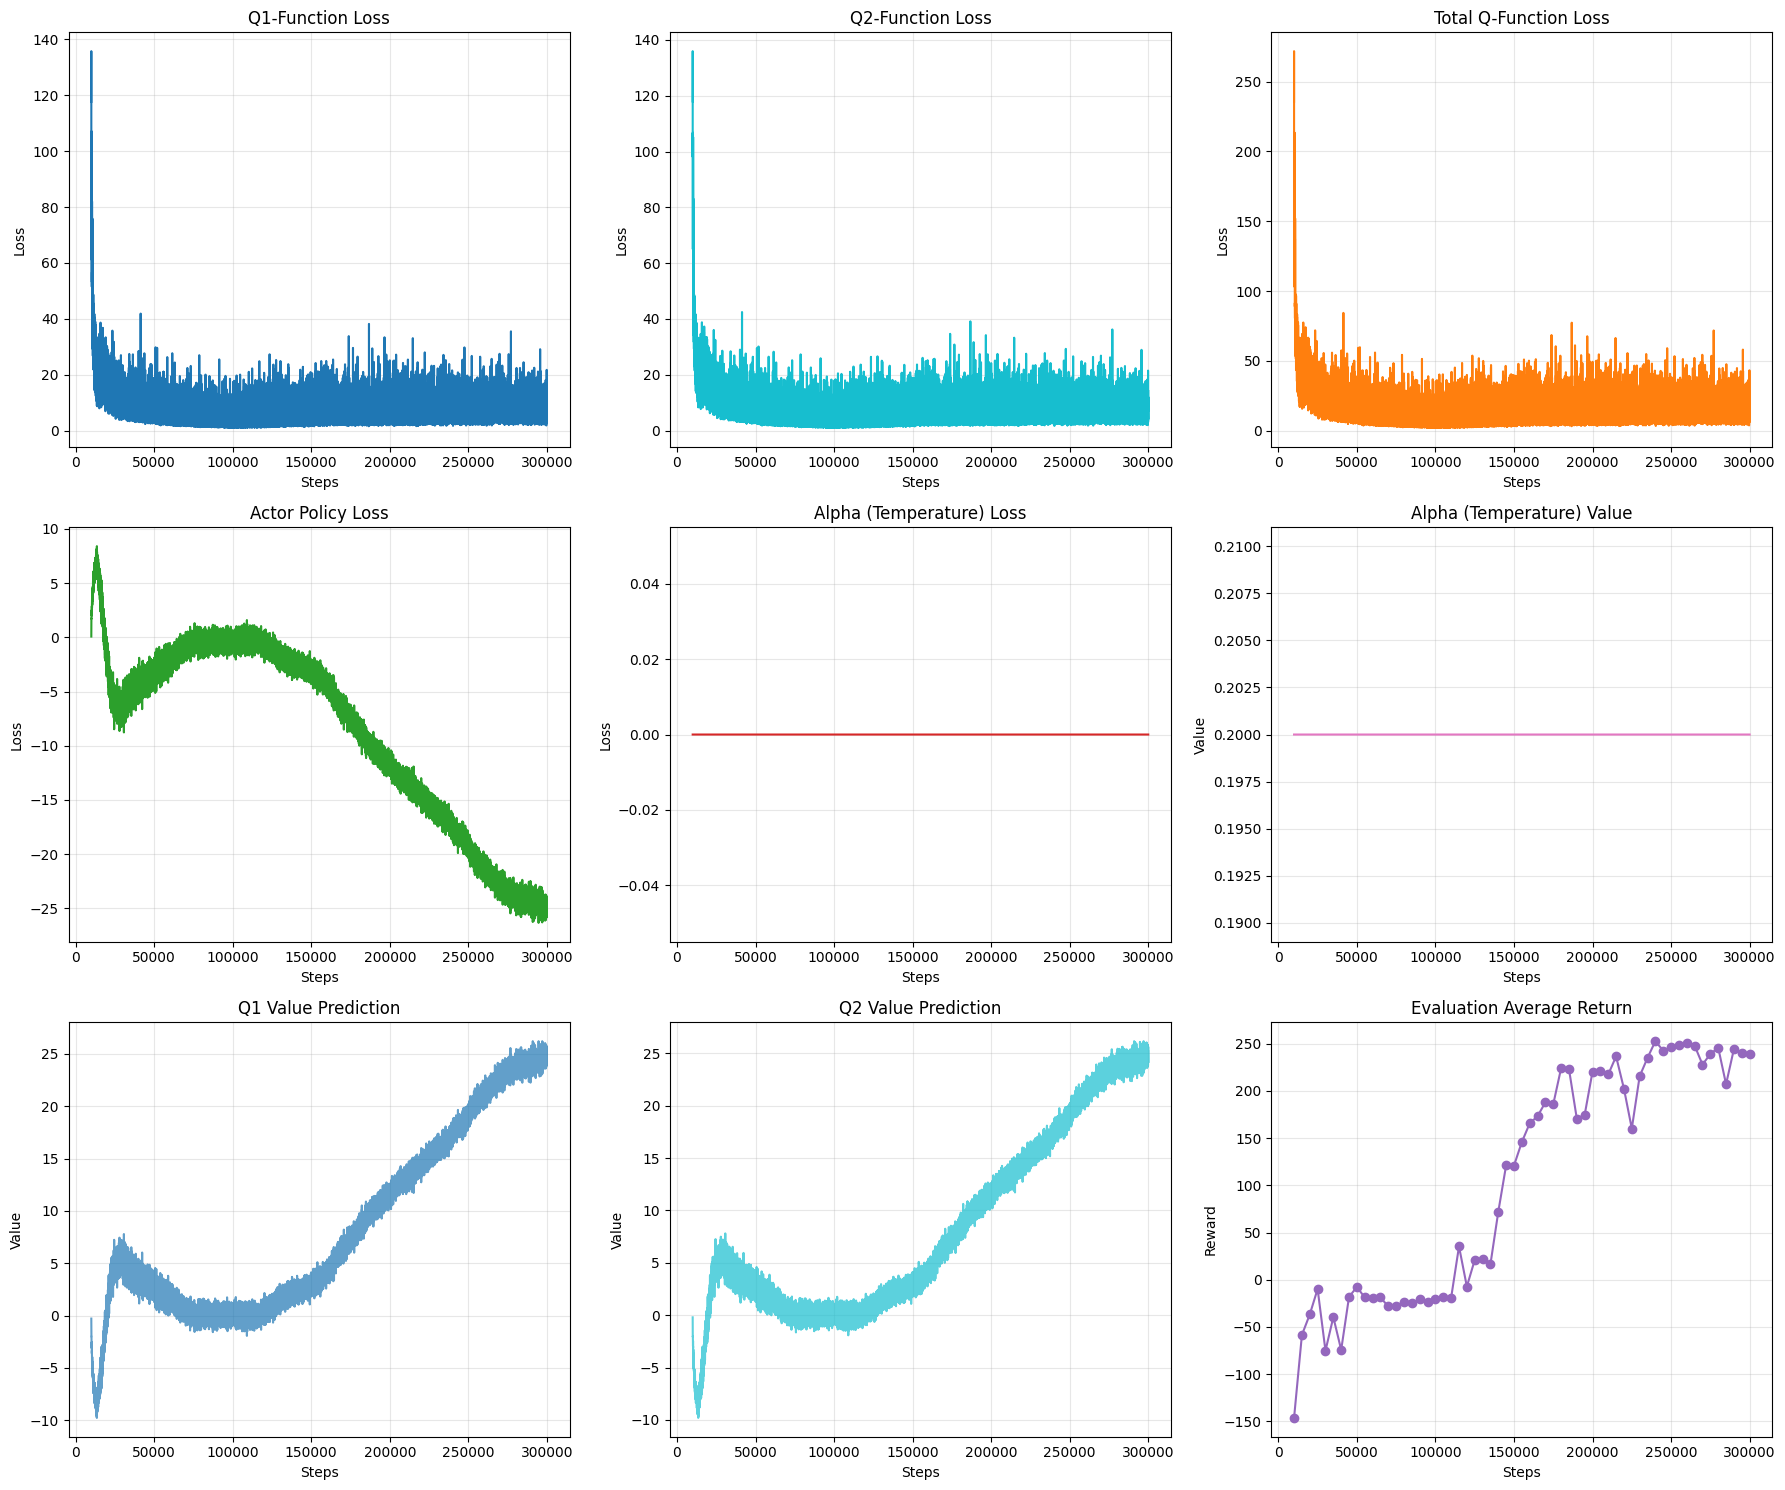

Model saved to sac_lunar_lander.pth


In [13]:
plot_training_results(
        history['update_steps'],
        history['q_l'],
        history['q1_l'],
        history['q2_l'],
        history['act_l'],
        history['alp_l'],
        history['alpha_v'],
        history['q1_val'],
        history['q2_val'],
        history['eval_steps'],
        history['eval_rets']
    )

# Save model
save_model(agent)

In [14]:
from IPython.display import Image, display

def record_gif(checkpoint_path: str, filename: str = 'simulation.gif') -> str:
    """Load a trained model and generate a simulation GIF.

    Args:
        checkpoint_path: Path to saved model weights
        filename: Output GIF filename

    Returns:
        Path to the generated GIF file
    """
    import imageio

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Reconstruct environment parameters
    temp_env = gym.make(args.env_name)
    obs_dim = temp_env.observation_space.shape[0]
    act_dim = temp_env.action_space.shape[0]
    act_limit = float(temp_env.action_space.high[0])
    temp_env.close()

    # Initialize Agent with the SAME hidden_sizes used during training
    agent = SACAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        act_limit=act_limit,
        device=device,
        hidden_sizes=args.hidden_sizes
    )

    # Load the checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device)
    agent.actor.load_state_dict(checkpoint['actor_state_dict'])
    agent.q1.load_state_dict(checkpoint['q1_state_dict'])
    agent.q2.load_state_dict(checkpoint['q2_state_dict'])
    if agent.auto_alpha and checkpoint['log_alpha'] is not None:
        agent.log_alpha.data.copy_(checkpoint['log_alpha'].data)

    env = gym.make(args.env_name, render_mode='rgb_array')
    obs, _ = env.reset(seed=42)
    frames = []
    done = False
    truncated = False
    total_reward = 0

    print(f"Simulating using {checkpoint_path}...")
    while not (done or truncated):
        frames.append(env.render())
        action = agent.select_action(obs, deterministic=True)
        obs, reward, done, truncated, _ = env.step(action)
        total_reward += reward

    env.close()
    print(f"Total Reward: {total_reward:.2f}")
    imageio.mimsave(filename, frames, fps=30)
    return filename

Simulating using /kaggle/working/sac_lunar_lander.pth...
Total Reward: 207.26


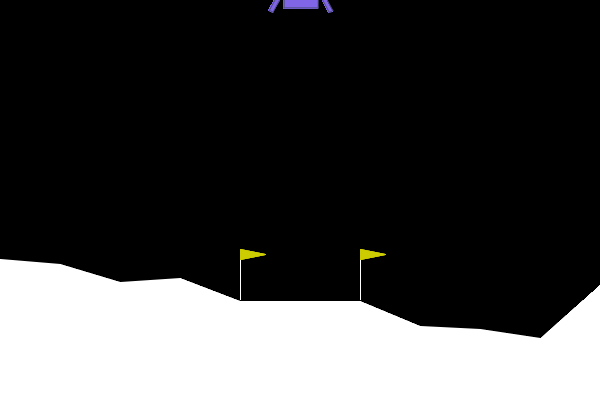

In [16]:
# Re-run the recording with the corrected function parameters
gif_path = record_gif('/kaggle/working/sac_lunar_lander.pth')
display(Image(filename=gif_path))